<a href="https://colab.research.google.com/github/MarkDeng86/VolatilityPredictionDeepLearning/blob/GARCH/%E2%80%9COptiverRV_ipynb%E2%80%9D%E7%9A%84%E5%89%AF%E6%9C%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title
# importing kaggle competition dataset
# make sure to upload kaggle.json to google drive
competition_name = "optiver-realized-volatility-prediction"

# Mount your Google Drive.
from google.colab import drive
drive.mount("/content/drive")

kaggle_creds_path = "/content/drive/MyDrive/kaggle.json"

! pip install kaggle --quiet
! cp /content/drive/MyDrive/kaggle.json ~/.kaggle/
! mkdir ~/.kaggle

! kaggle competitions download -c {competition_name}

! mkdir kaggle_data
! unzip {competition_name + ".zip"} -d kaggle_data

# Unmount your Google Drive
drive.flush_and_unmount()

### IGNORE THIS CELL

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cp: cannot stat '/content/drive/MyDrive/kaggle.json': No such file or directory
mkdir: cannot create directory ‘/root/.kaggle’: File exists
You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication
mkdir: cannot create directory ‘kaggle_data’: File exists
unzip:  cannot find or open optiver-realized-volatility-prediction.zip, optiver-realized-volatility-prediction.zip.zip or optiver-realized-volatility-prediction.zip.ZIP.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(2026)
DATA_DIR = '/content/drive/MyDrive/TimeSeriesDeepLearning_FIM601/kaggle_data/optiver-realized-volatility-prediction'

### Mark: Below I am testing implementation with polars for more efficient data manipulation. We can translate pandas manipulation to polars pretty easily.

In [4]:
import polars as pl

In [5]:
pl_lazy_book_train = pl.scan_parquet(f'{DATA_DIR}/book_train.parquet', hive_partitioning=True)

In [6]:
# checking book data schema
check_pl = pl.read_parquet_schema(f'{DATA_DIR}/book_train.parquet/stock_id=0/c439ef22282f412ba39e9137a3fdabac.parquet')
print(check_pl)

Schema({'time_id': Int16, 'seconds_in_bucket': Int16, 'bid_price1': Float32, 'ask_price1': Float32, 'bid_price2': Float32, 'ask_price2': Float32, 'bid_size1': Int32, 'ask_size1': Int32, 'bid_size2': Int32, 'ask_size2': Int32})


In [7]:
# TRANSFORM: Define your preprocessing steps
# Polars builds an optimized query plan for these operations
processed_book = (
    pl_lazy_book_train
    # OPTIMIZATION: Convert stock_id to Int8 early to save memory
    .with_columns(pl.col("stock_id").cast(pl.Int8))
    # Ensure correct ordering for time-based calculations
    .sort(["stock_id", "time_id", "seconds_in_bucket"])

    .with_columns(
        # Calculate the primary WAP (Weighted Average Price)
        wap1 = ((pl.col("bid_price1") * pl.col("ask_size1") +
                pl.col("ask_price1") * pl.col("bid_size1")) /
                (pl.col("bid_size1") + pl.col("ask_size1"))).cast(pl.Float32),

        wap2 = ((pl.col("bid_price2") * pl.col("ask_size2") +
                pl.col("ask_price2") * pl.col("bid_size2")) /
                (pl.col("bid_size2") + pl.col("ask_size2"))).cast(pl.Float32),

        # Calculate the level 1 Bid-Ask spread
        spread1 = (pl.col("ask_price1") - pl.col("bid_price1")).cast(pl.Float32),

        # Calculate the level 1 and level 1&2 volume
        vol_l1 = (pl.col("bid_size1") + pl.col("ask_size1")),
        vol_l2 = (pl.col("bid_size2") + pl.col("ask_size2")),

        # Calculate the mid-price
        mid_price = ((pl.col("bid_price1") + pl.col("ask_price1")) / 2).cast(pl.Float32)
    )
    .with_columns(
        # Calculate the total volume
        vol_total = (pl.col("vol_l1") + pl.col("vol_l2")),

        # Calculate the volume imbalance -> Float32
        vol_imbalance = ((pl.col("bid_size1") - pl.col("ask_size1")) /
                        (pl.col("bid_size1") + pl.col("ask_size1"))).cast(pl.Float32),

        wap_basis = (pl.col("wap1") - pl.col("wap2")).cast(pl.Float32)
    )

    # Time-Based Features
    .with_columns(
        # Create 60-second micro-buckets
        minute_in_bucket = (pl.col("seconds_in_bucket") // 60).cast(pl.Int8),

        # Calculate time elapsed since last update
        time_since_last_update = (
            pl.col("seconds_in_bucket") - pl.col("seconds_in_bucket")
            .shift(1)
            .over(["stock_id", "time_id"])
        ).fill_null(0).cast(pl.Int16)
    )

    # Lagged Variables
    .with_columns(
        # Tick-to-tick Log Return of WAP
        log_return_1t = (
            pl.col("wap1").log() - pl.col("wap1").shift(1).log()
        ).over(["stock_id", "time_id"]).fill_null(0).cast(pl.Float32),

        # Spread change
        spread_change = (
            pl.col("spread1") - pl.col("spread1").shift(1)
        ).over(["stock_id", "time_id"]).fill_null(0).cast(pl.Float32)
    )
    .with_columns(
        # Squared returns
        log_return_sq = (pl.col("log_return_1t") ** 2).cast(pl.Float32)
    )
    .with_columns(
        # Realized volatility
        realized_volatility = pl.col("log_return_sq").sum().sqrt().over(["stock_id", "time_id"]).cast(pl.Float32)
    )

    # Rolling window statistics
    .with_columns(
        # 10-tick rolling mean of spread
        spread_rolling_mean_10t = (
            pl.col("spread1")
            .rolling_mean(window_size=10, min_samples=1) # min_samples overides min tick count require for 10t statistics; addressing null values
            .over(["stock_id", "time_id"])
        ).cast(pl.Float32),

        # 20-tick rolling std of log returns
        volatility_rolling_20t = (
            pl.col("log_return_1t")
            .rolling_std(window_size=20, min_samples=2)
            .over(["stock_id", "time_id"])
        ).cast(pl.Float32),

        # Moving sum of order flow imbalance
        order_flow_imbalance_15t = (
            (pl.col("bid_size1") - pl.col("ask_size1"))
            .rolling_sum(window_size=15, min_samples=1)
            .over(["stock_id", "time_id"])
        ).cast(pl.Int32)
    )
)

In [8]:
# Group by stock and time, then calculate summary statistics (e.g., standard deviation of WAP)
aggregated_features = (
    processed_book
    .group_by(["stock_id", "time_id"])
    .agg(
        # Example feature: Realized volatility (std dev of log returns or WAP variations)
        realized_volatility = pl.col("log_return_sq").sum().sqrt(),
        wap1_mean = pl.col("wap1").mean(),

        # Average spread over the time bucket
        mean_spread = pl.col("spread1").mean(),

        # Count the number of updates in this bucket
        update_count = pl.col("seconds_in_bucket").count(),

        # ---- Volume Features ----
        # vol_mean = pl.col("vol_total").mean(),
        # vol_std = pl.col("vol_total").std(),
        vol_sum = pl.col("vol_total").sum(),

        vol_90 = pl.col("vol_total").quantile(0.9),
        # vol_99 = pl.col("vol_total").quantile(0.99),

        vol_imbalance_mean = pl.col("vol_imbalance").mean(),
        vol_imbalance_std = pl.col("vol_imbalance").std()
    )
)

In [9]:
df_small = (
    processed_book
    .select([
        "stock_id",
        "time_id",
        "seconds_in_bucket",
        "mid_price"
    ])
    .collect()
)

In [10]:
print(df_small.head())

shape: (5, 4)
┌──────────┬─────────┬───────────────────┬───────────┐
│ stock_id ┆ time_id ┆ seconds_in_bucket ┆ mid_price │
│ ---      ┆ ---     ┆ ---               ┆ ---       │
│ i8       ┆ i16     ┆ i16               ┆ f32       │
╞══════════╪═════════╪═══════════════════╪═══════════╡
│ 0        ┆ 5       ┆ 0                 ┆ 1.001862  │
│ 0        ┆ 5       ┆ 1                 ┆ 1.001862  │
│ 0        ┆ 5       ┆ 5                 ┆ 1.001862  │
│ 0        ┆ 5       ┆ 6                 ┆ 1.001862  │
│ 0        ┆ 5       ┆ 7                 ┆ 1.001862  │
└──────────┴─────────┴───────────────────┴───────────┘


In [11]:
df_small = df_small.sort(["stock_id", "time_id", "seconds_in_bucket"])
df_small = df_small.with_columns([
    (
        pl.col("mid_price")
        .log()
        .diff()
        .over("stock_id")
    ).alias("log_return")
])

# realized_vol = (
#     df_small
#     .group_by(["stock_id", "time_id"])
#     .agg([
#         (pl.col("log_return") ** 2).sum().sqrt().alias("realized_volatility")
#     ])
#     .sort(["stock_id", "time_id"])
# )

# print(realized_vol.head())

In [12]:
stock_df = (
    df_small
    .filter(pl.col("stock_id") == 0)
    .sort(["time_id", "seconds_in_bucket"])
)

returns = (
    stock_df
    .select("log_return")
    .drop_nulls()
    .to_numpy()
    .flatten()
)

returns = returns * 1e4 # this scale comes from the GARCH model built for raw returns data
print(returns)

[0. 0. 0. ... 0. 0. 0.]


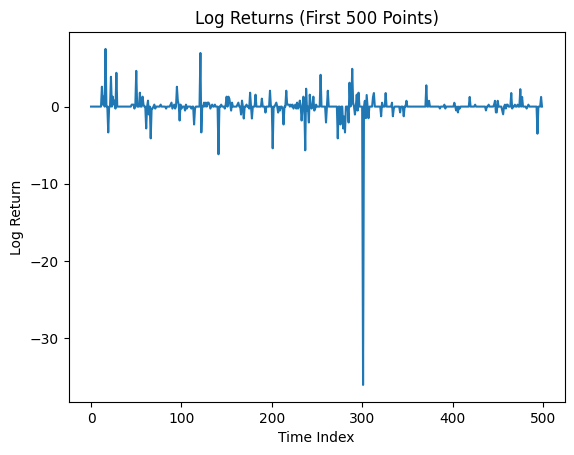

In [13]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(returns[:500])   # first 500 points
plt.title("Log Returns (First 500 Points)")
plt.xlabel("Time Index")
plt.ylabel("Log Return")
plt.show()

In [14]:
len(returns)

917552

In [15]:
# # Stationary test
# sample = returns[:50000]

# from statsmodels.tsa.stattools import adfuller
# stat, pval, *_ = adfuller(sample)

# print(f"{pval:.10f}")

In [16]:
# from statsmodels.graphics.tsaplots import plot_acf
# import matplotlib.pyplot as plt

# plot_acf(returns[:50000], lags=20)

In [17]:
# plot_acf(returns[:50000]**2, lags=30)

In [18]:
!pip install arch

In [19]:
from arch import arch_model

model = arch_model(
    returns,
    mean="Zero",
    vol="Garch",
    p=1,
    q=1
)

res = model.fit(disp="off")

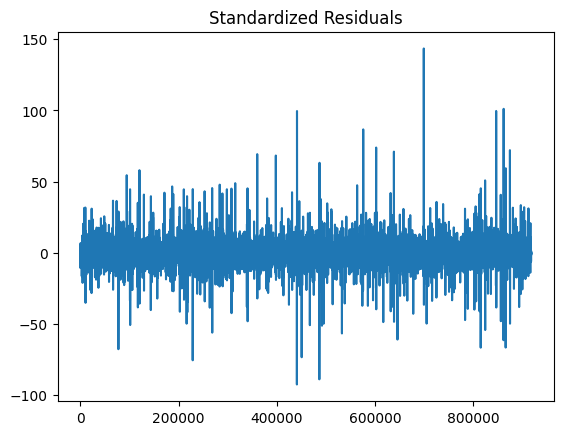

In [20]:
std_resid = res.resid / res.conditional_volatility

plt.plot(std_resid)
plt.title("Standardized Residuals")
plt.show()

In [21]:
# Switch model to t-dist
model = arch_model(
    returns,
    mean="Zero",
    vol="GARCH",
    p=1,
    q=1,
    dist="t"
)

res = model.fit(disp="off")

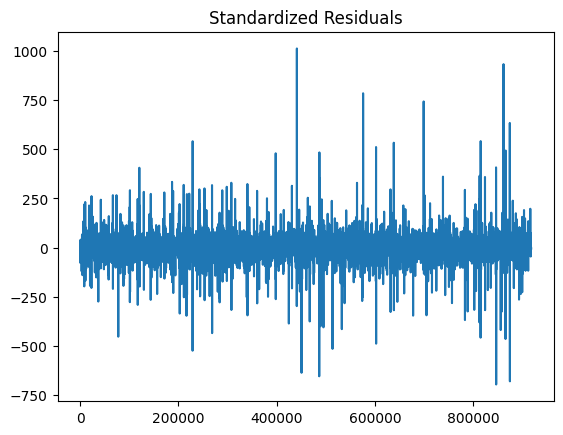

In [22]:
std_resid = res.resid / res.conditional_volatility

plt.plot(std_resid)
plt.title("Standardized Residuals")
plt.show()

In [23]:
# x = std_resid[::20]
# plot_acf(x**2, lags=30)

In [24]:
# from statsmodels.stats.diagnostic import acorr_ljungbox

# print(acorr_ljungbox(x**2, lags=[10], return_df=True))

In [25]:
# con_vol = res.conditional_volatility
# print(con_vol)

In [26]:
df_vol = (
    df_small
    .group_by(["stock_id", "time_id"])
    .agg([
        (pl.col("log_return")**2).sum().sqrt().alias("realized_vol")
    ])
    .sort(["stock_id", "time_id"])
)

In [27]:
df_vol = df_vol.with_columns(
    pl.col("realized_vol")
    .shift(1)
    .over("stock_id")
    .alias("lag_vol")
)

In [29]:
from arch import arch_model
import numpy as np

preds = []

for stock in df_small["stock_id"].unique():

    df_stock = df_small.filter(pl.col("stock_id") == stock).sort("time_id")

    # aggregate returns per time_id
    df_grouped = (
        df_stock
        .group_by("time_id")
        .agg(pl.col("log_return"))
        .sort("time_id")
    )

    # flatten returns across time
    returns = np.concatenate([
    np.array(x, dtype=float) for x in df_grouped["log_return"]
])

    # clean
    returns = returns[~np.isnan(returns)]
    returns = returns[np.isfinite(returns)]

    if len(returns) < 20:
        continue

    # scale
    returns = returns * 100

    try:
        model = arch_model(returns, vol="Garch", p=1, q=1)
        res = model.fit(disp="off")

        # forecast for all steps
        forecasts = res.forecast(horizon=1, start=0)
        variances = forecasts.variance.values.flatten()

    except:
        variances = np.full(len(df_grouped), np.nan)

    # map back to time_ids
    for i, time_id in enumerate(df_grouped["time_id"]):

        if i >= len(variances) or np.isnan(variances[i]) or variances[i] <= 0:
            pred_vol = np.std(returns)
        else:
            pred_vol = np.sqrt(variances[i])

        preds.append({
            "stock_id": stock,
            "time_id": time_id,
            "target": pred_vol / 100
        })

print("Total predictions:", len(preds))

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001469. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/tmp/ipykernel_63746/544915046.py:35: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  res = model.fit(disp="off")
/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001252. Parameter
estimation work better when this value is between 1 and 1000. The recommended
resca

Total predictions: 428932


/tmp/ipykernel_63746/544915046.py:35: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  res = model.fit(disp="off")


In [30]:
df_pred = pl.DataFrame(preds)

df_pred = df_pred.with_columns(
    (pl.col("stock_id").cast(pl.Utf8) + "-" + pl.col("time_id").cast(pl.Utf8)).alias("row_id")
)

df_pred = df_pred.select(["row_id", "target"]).sort("row_id")

df_pred.write_csv("/content/drive/MyDrive/submission.csv")